In [1]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from dragonnet import Dragonnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
sys.path.append("..")
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [2]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 15.5 ms, sys: 1.95 ms, total: 17.5 ms
Wall time: 17 ms
CPU times: user 4.3 ms, sys: 3.04 ms, total: 7.34 ms
Wall time: 7.34 ms
CPU times: user 3.2 ms, sys: 0 ns, total: 3.2 ms
Wall time: 3.21 ms


In [3]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', "channel"]
label_feature = ['spend']
treatment_feature = ['treatment']

In [ ]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel','history_segment', 'mens', 'womens', 'newbie'] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 6 lớp Embedding và 2 lớp Projection.


/tmp/ipykernel_1628355/910850196.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)


🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 1096.9640 | Tarreg Loss: 553.087097 | Total Loss: 1650.0510 | Val Loss: 621.4660 | Val Qini: 0.8053 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 398.7195 | Tarreg Loss: 203.995499 | Total Loss: 602.7150 | Val Loss: 621.6511 | Val Qini: 0.7933 (patience: 1/20)
Epoch 3/150 | Base Loss: 781.9157 | Tarreg Loss: 391.325317 | Total Loss: 1173.2410 | Val Loss: 621.3968 | Val Qini: 0.8352 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 277.2007 | Tarreg Loss: 138.115265 | Total Loss: 415.3160 | Val Loss: 620.6059 | Val Qini: 0.7764 ⭐ NEW BEST (lowest loss)
Epoch 5/150 | Base Loss: 250.3074 | Tarreg Loss: 122.732307 | Total Loss: 373.0397 | Val Loss: 620.7608 | Val Qini: 0.7614 (patience: 1/20)
Epoch 6/150 | Base Loss: 171.6881 | Tarreg Loss: 86.291039 | Total Loss: 257.9791 | Val Lo

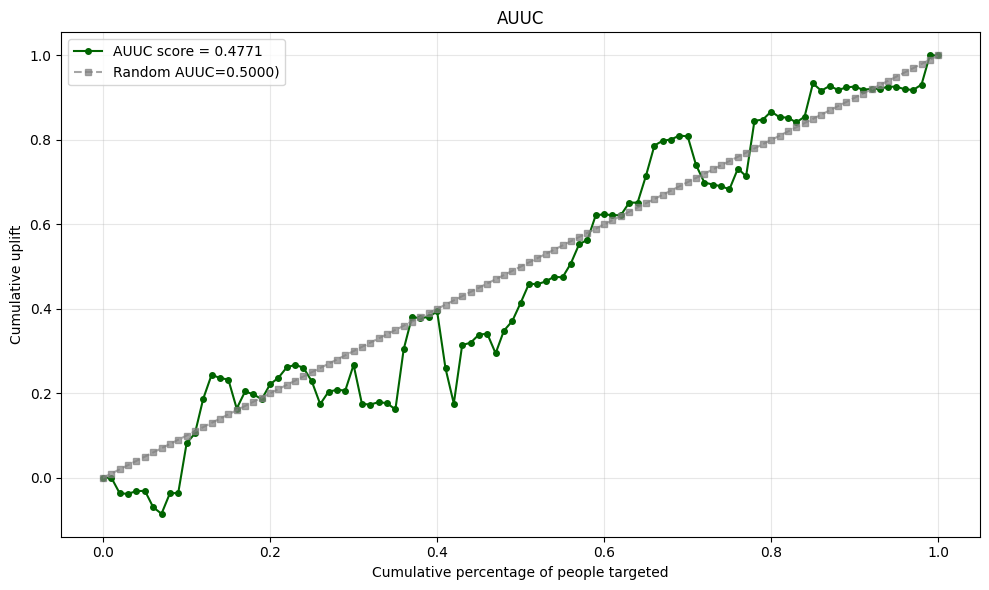

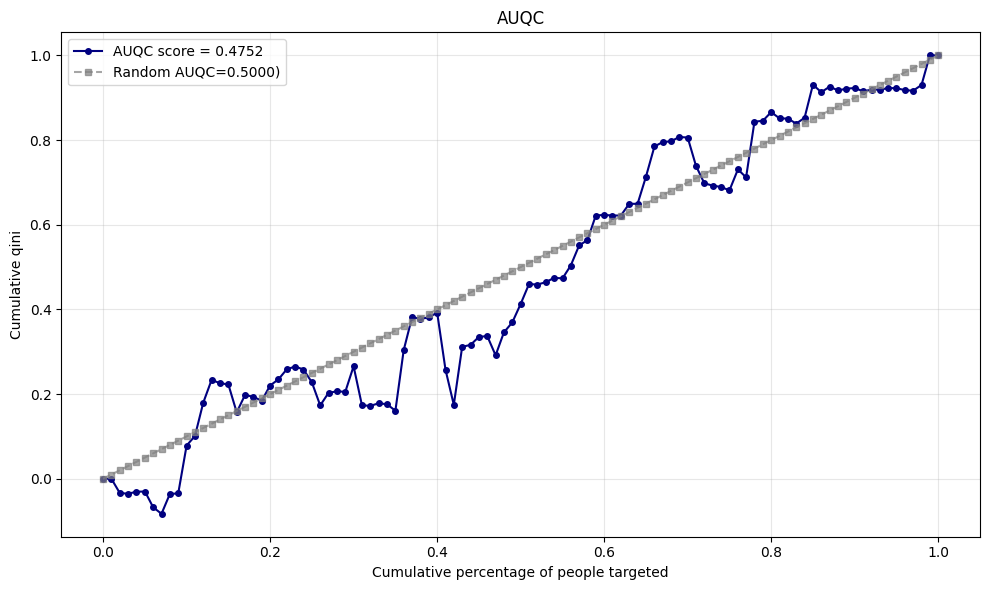

Done Seed 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 587.2567 | Tarreg Loss: 297.873993 | Total Loss: 885.1307 | Val Loss: 621.7794 | Val Qini: 0.6834 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 88.2664 | Tarreg Loss: 45.241543 | Total Loss: 133.5079 | Val Loss: 621.7470 | Val Qini: 0.7341 ⭐ NEW BEST (lowest loss)
Epoch 3/150 | Base Loss: 724.0498 | Tarreg Loss: 358.819977 | Total Loss: 1082.8698 | Val Loss: 621.3763 | Val Qini: 0.7270 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 88.6611 | Tarreg Loss: 45.454895 | Total Loss: 134.1160 | Val Loss: 620.8735 | Val Qini: 0.7572 ⭐ NEW BEST (lowest loss)
Epoch 5/150 | Base Loss: 319.8353 | Tarreg Loss: 161.821457 | Total Loss: 481.6567 | Val Loss: 621.3359 | Val Qini: 0.8120 (patience: 1/20)
Epoch 6/150 | Base Loss: 158.1991 | Tarreg Loss: 77.866371 | Total Loss

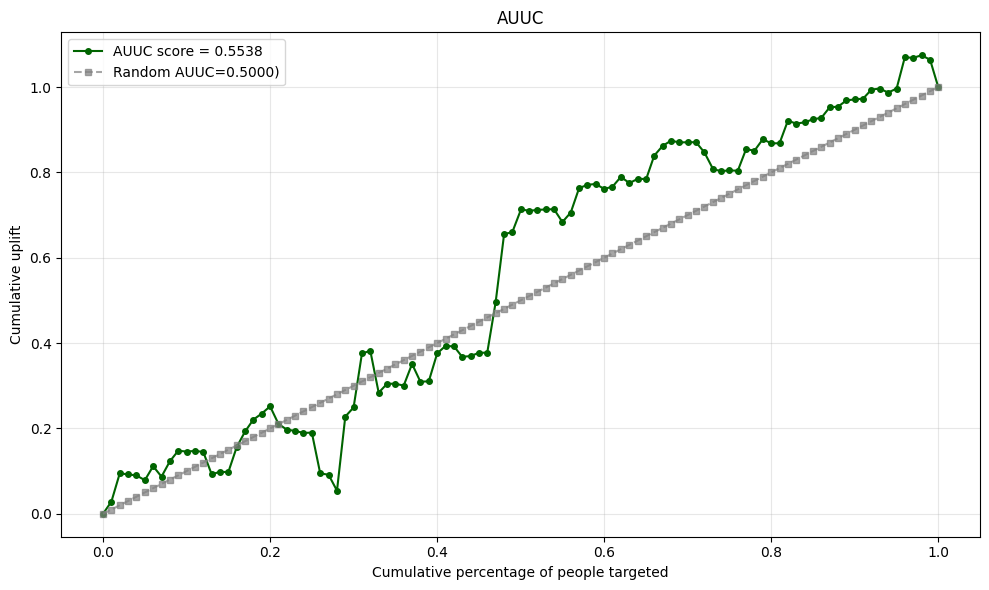

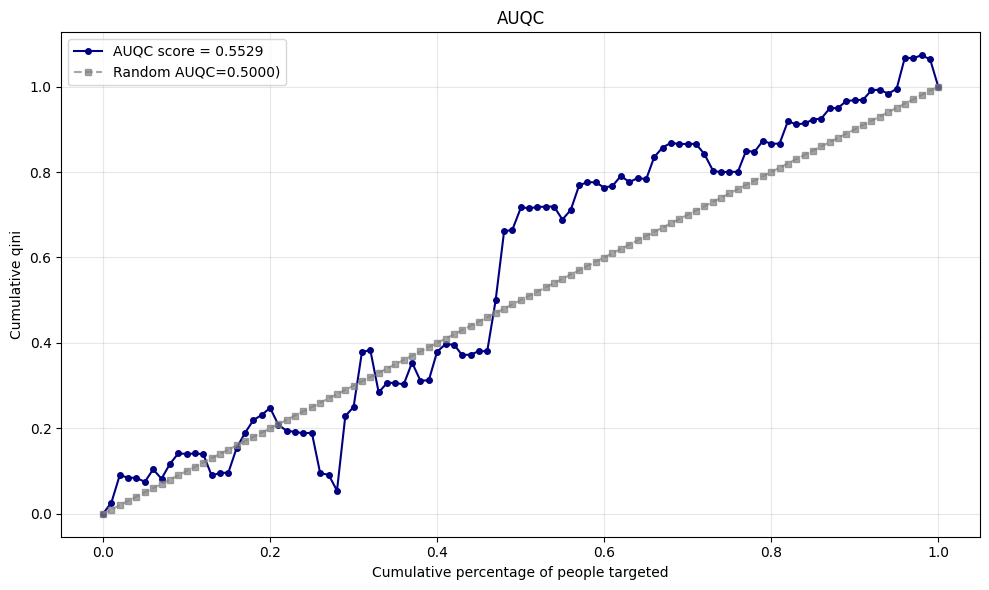

Done Seed 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 757.0585 | Tarreg Loss: 357.611542 | Total Loss: 1114.6700 | Val Loss: 623.7475 | Val Qini: 0.1582 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 590.7781 | Tarreg Loss: 318.176666 | Total Loss: 908.9547 | Val Loss: 622.9688 | Val Qini: 0.2351 ⭐ NEW BEST (lowest loss)
Epoch 3/150 | Base Loss: 681.8292 | Tarreg Loss: 350.867401 | Total Loss: 1032.6965 | Val Loss: 622.1308 | Val Qini: 0.7399 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 608.4954 | Tarreg Loss: 316.241364 | Total Loss: 924.7367 | Val Loss: 622.1323 | Val Qini: 0.7206 (patience: 1/20)
Epoch 5/150 | Base Loss: 793.5164 | Tarreg Loss: 407.701263 | Total Loss: 1201.2177 | Val Loss: 621.5124 | Val Qini: 0.6682 ⭐ NEW BEST (lowest loss)
Epoch 6/150 | Base Loss: 352.9237 | Tarreg Loss: 166.884689 | Total L

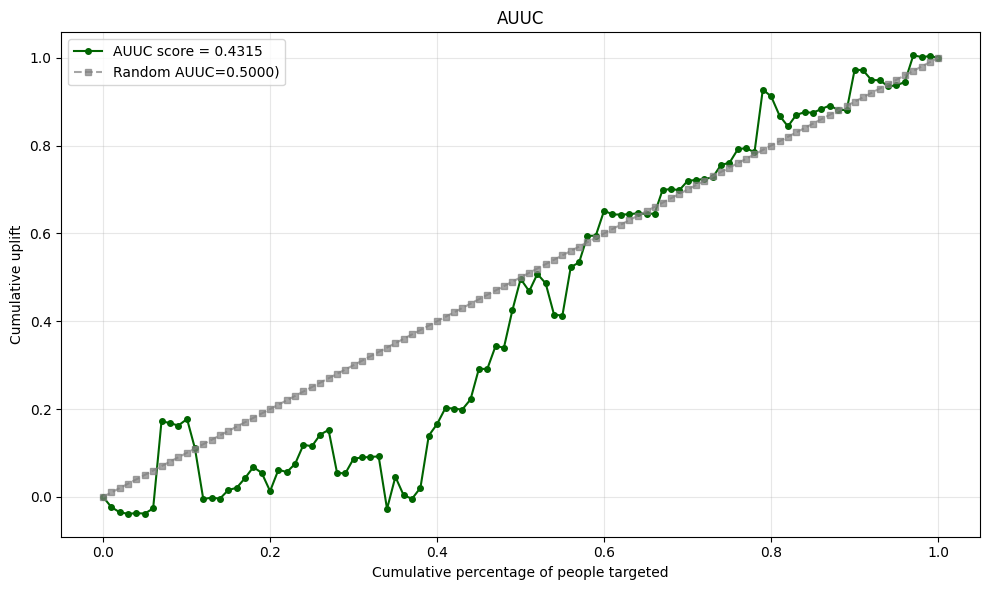

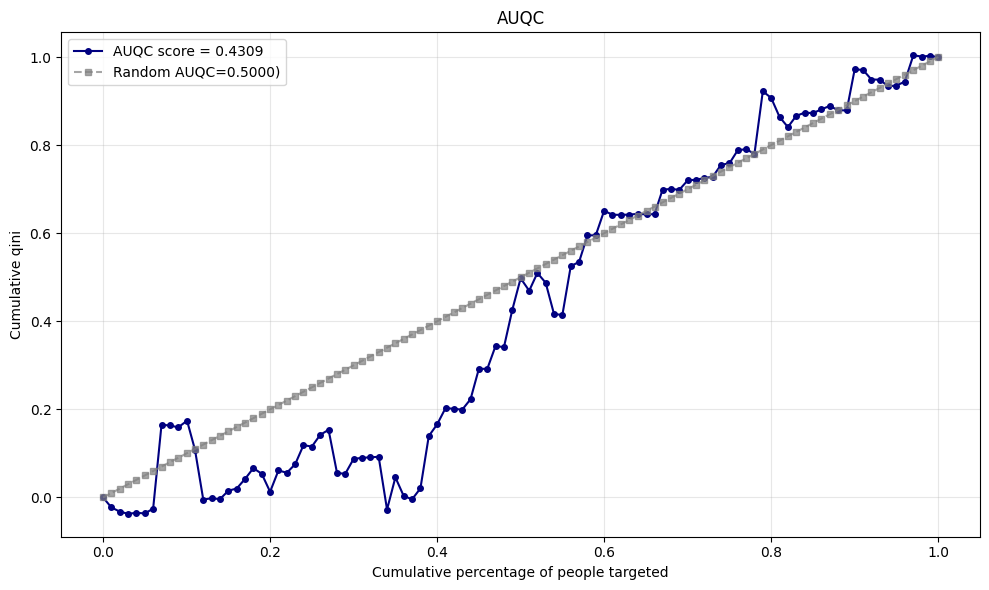

Done Seed 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 1031.7666 | Tarreg Loss: 523.286560 | Total Loss: 1555.0532 | Val Loss: 623.2040 | Val Qini: 0.5792 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 373.4883 | Tarreg Loss: 186.338516 | Total Loss: 559.8268 | Val Loss: 622.1572 | Val Qini: 0.5984 ⭐ NEW BEST (lowest loss)
Epoch 3/150 | Base Loss: 1288.6158 | Tarreg Loss: 645.915833 | Total Loss: 1934.5317 | Val Loss: 621.3751 | Val Qini: 0.6731 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 1040.4456 | Tarreg Loss: 520.818909 | Total Loss: 1561.2644 | Val Loss: 620.8705 | Val Qini: 0.6587 ⭐ NEW BEST (lowest loss)
Epoch 5/150 | Base Loss: 643.7349 | Tarreg Loss: 321.686432 | Total Loss: 965.4213 | Val Loss: 621.1675 | Val Qini: 0.6197 (patience: 1/20)
Epoch 6/150 | Base Loss: 719.3492 | Tarreg Loss: 358.781921 | To

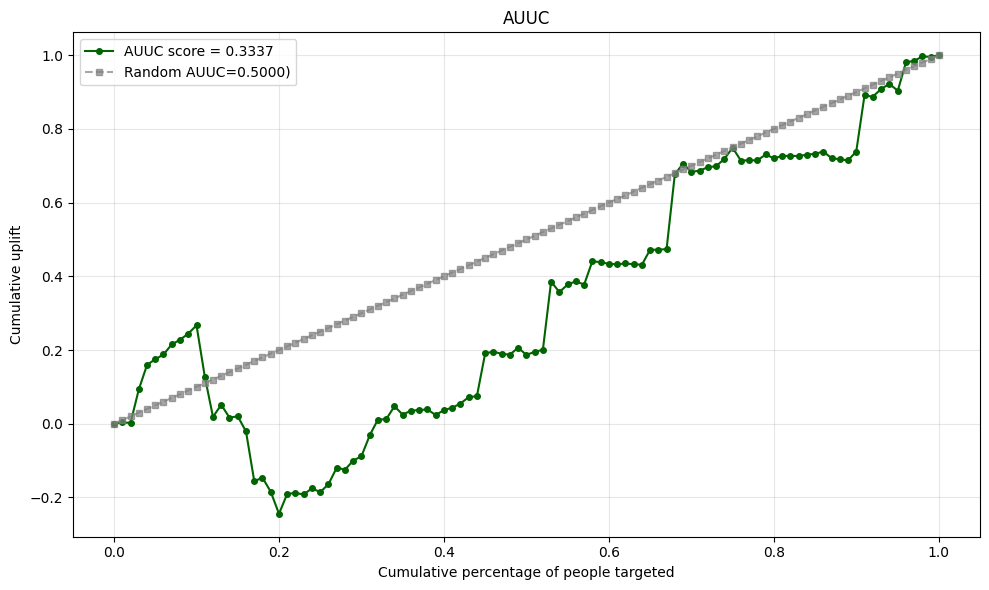

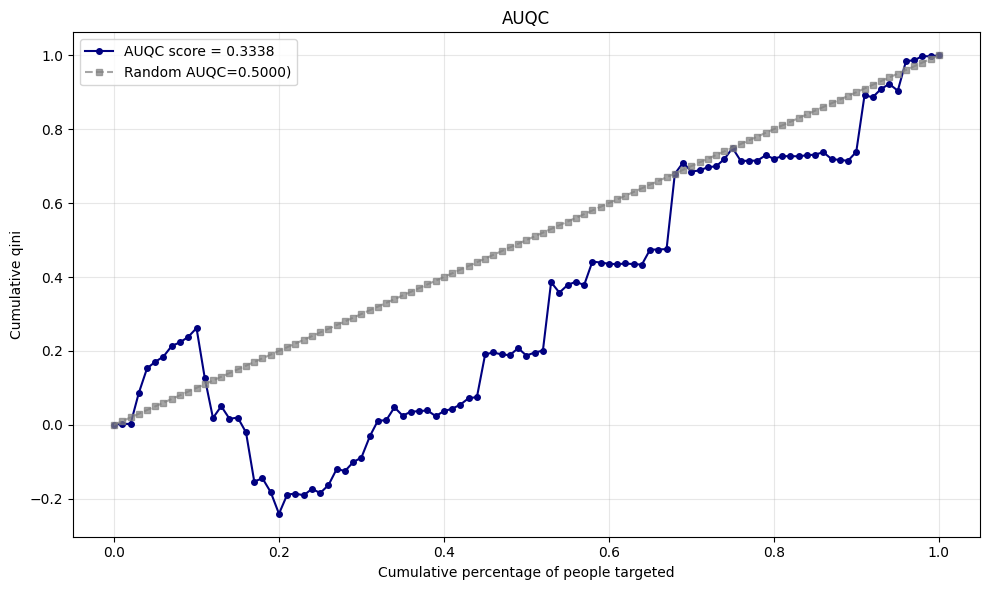

Done Seed 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 215.9440 | Tarreg Loss: 103.817879 | Total Loss: 319.7619 | Val Loss: 622.0473 | Val Qini: 0.6872 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 294.2730 | Tarreg Loss: 146.511978 | Total Loss: 440.7850 | Val Loss: 621.8762 | Val Qini: 0.6931 ⭐ NEW BEST (lowest loss)
Epoch 3/150 | Base Loss: 291.1164 | Tarreg Loss: 153.927689 | Total Loss: 445.0441 | Val Loss: 621.0299 | Val Qini: 0.7780 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 408.5773 | Tarreg Loss: 207.065796 | Total Loss: 615.6431 | Val Loss: 620.8842 | Val Qini: 0.7288 ⭐ NEW BEST (lowest loss)
Epoch 5/150 | Base Loss: 244.7099 | Tarreg Loss: 126.716217 | Total Loss: 371.4261 | Val Loss: 620.6064 | Val Qini: 0.7104 ⭐ NEW BEST (lowest loss)
Epoch 6/150 | Base Loss: 228.6793 | Tarreg Loss: 114.340042 

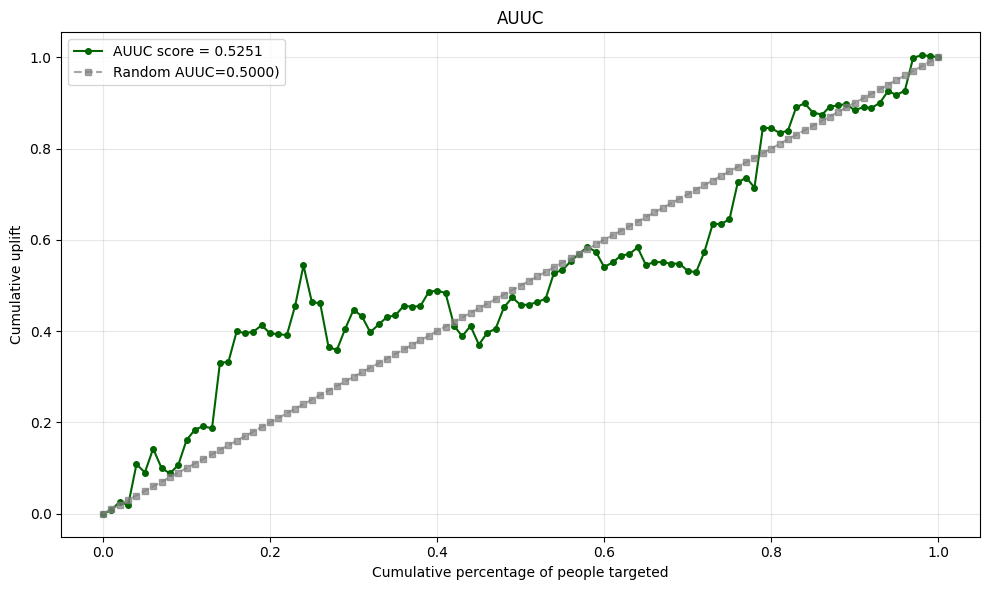

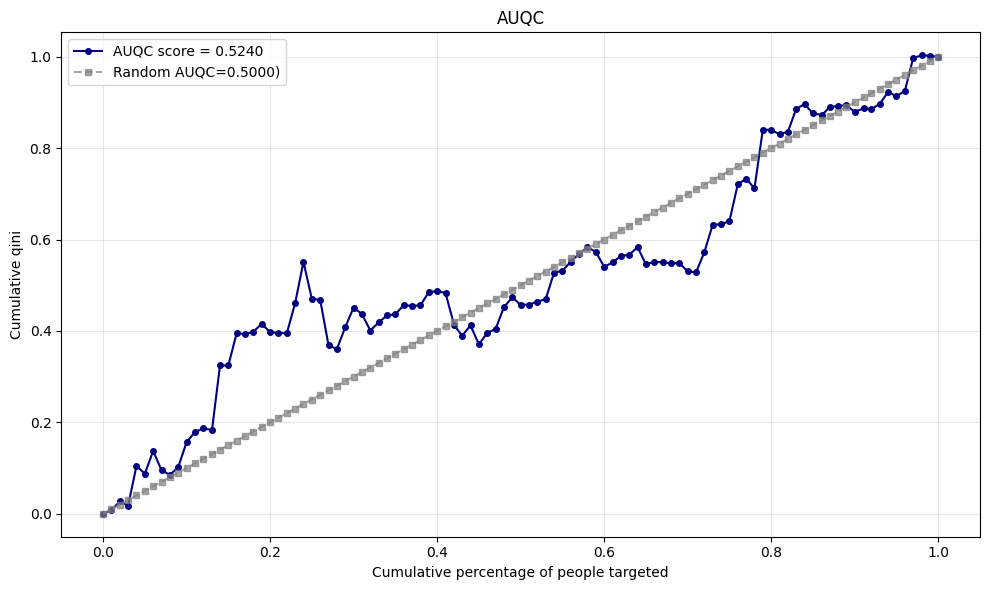

Done Seed 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 420.5407 | Tarreg Loss: 211.004532 | Total Loss: 631.5452 | Val Loss: 623.4414 | Val Qini: 0.7660 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 190.6970 | Tarreg Loss: 94.692596 | Total Loss: 285.3896 | Val Loss: 622.7571 | Val Qini: 0.8121 ⭐ NEW BEST (lowest loss)
Epoch 3/150 | Base Loss: 700.9774 | Tarreg Loss: 350.456177 | Total Loss: 1051.4336 | Val Loss: 623.0218 | Val Qini: 0.7711 (patience: 1/20)
Epoch 4/150 | Base Loss: 271.6144 | Tarreg Loss: 140.658691 | Total Loss: 412.2731 | Val Loss: 622.7844 | Val Qini: 0.7437 (patience: 2/20)
Epoch 5/150 | Base Loss: 252.8150 | Tarreg Loss: 127.950111 | Total Loss: 380.7651 | Val Loss: 622.9675 | Val Qini: 0.6922 (patience: 3/20)
Epoch 6/150 | Base Loss: 298.8470 | Tarreg Loss: 149.250656 | Total Loss: 448.0977 | Val 

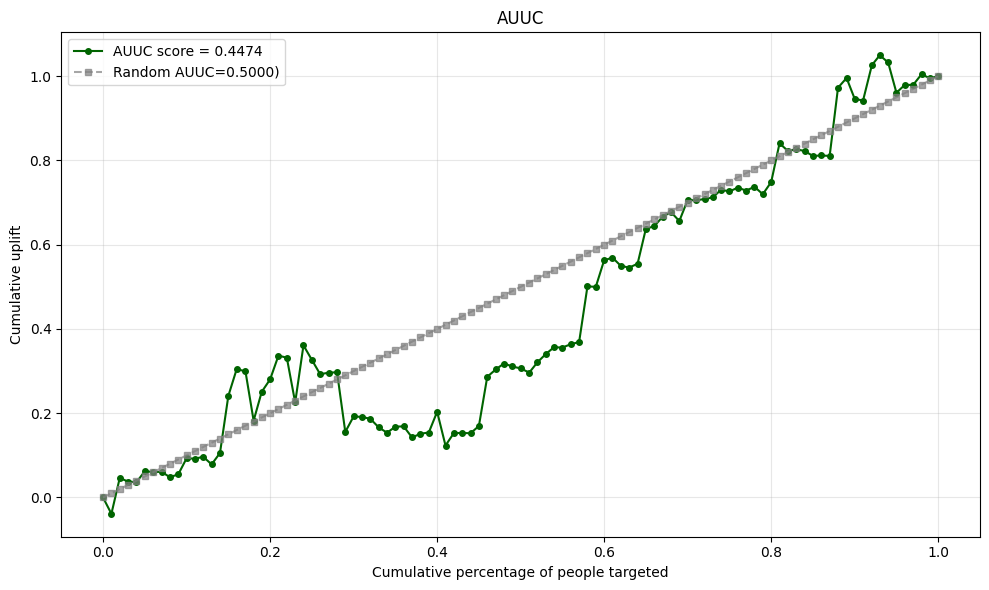

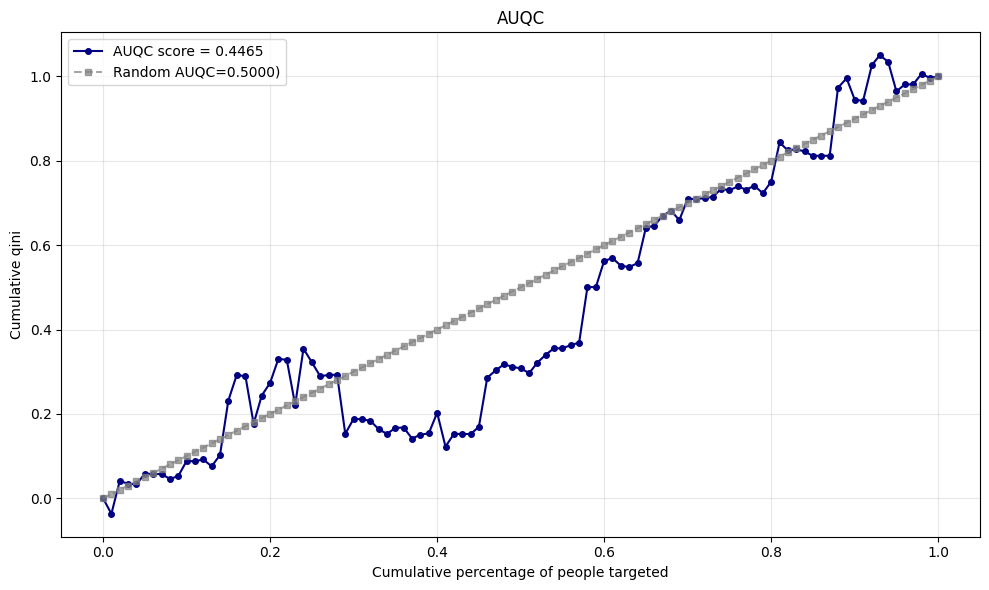

Done Seed 2
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 301.3348 | Tarreg Loss: 153.325073 | Total Loss: 454.6599 | Val Loss: 629.2288 | Val Qini: 0.1069 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 360.2984 | Tarreg Loss: 181.357864 | Total Loss: 541.6563 | Val Loss: 628.1643 | Val Qini: 0.2264 ⭐ NEW BEST (lowest loss)
Epoch 3/150 | Base Loss: 447.5469 | Tarreg Loss: 234.153885 | Total Loss: 681.7008 | Val Loss: 628.0260 | Val Qini: 0.2285 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 321.6251 | Tarreg Loss: 160.265976 | Total Loss: 481.8911 | Val Loss: 627.2697 | Val Qini: 0.2816 ⭐ NEW BEST (lowest loss)
Epoch 5/150 | Base Loss: 94.8188 | Tarreg Loss: 52.440853 | Total Loss: 147.2596 | Val Loss: 627.0648 | Val Qini: 0.4630 ⭐ NEW BEST (lowest loss)
Epoch 6/150 | Base Loss: 84.2052 | Tarreg Loss: 49.838387 | Total L

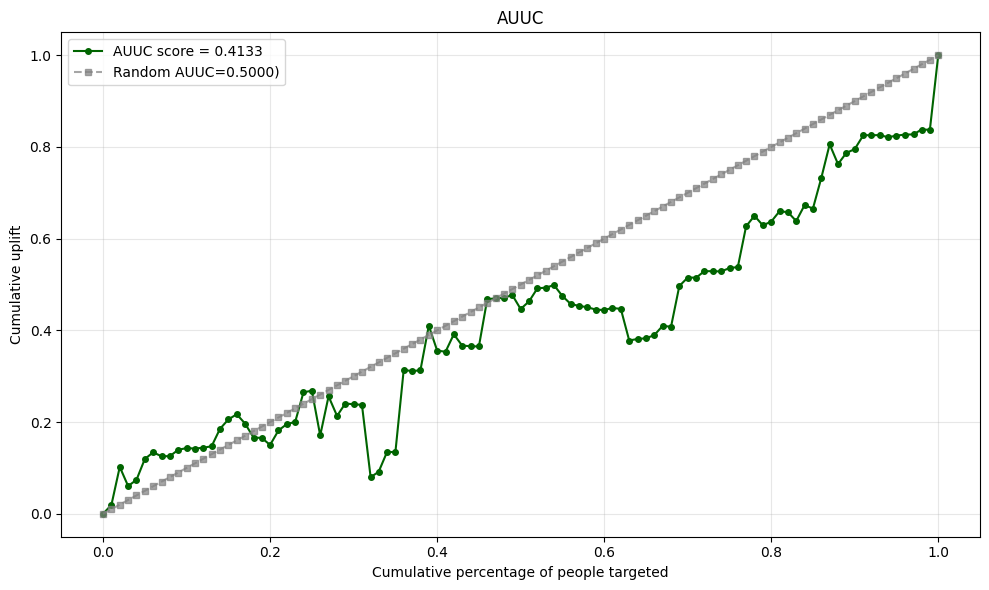

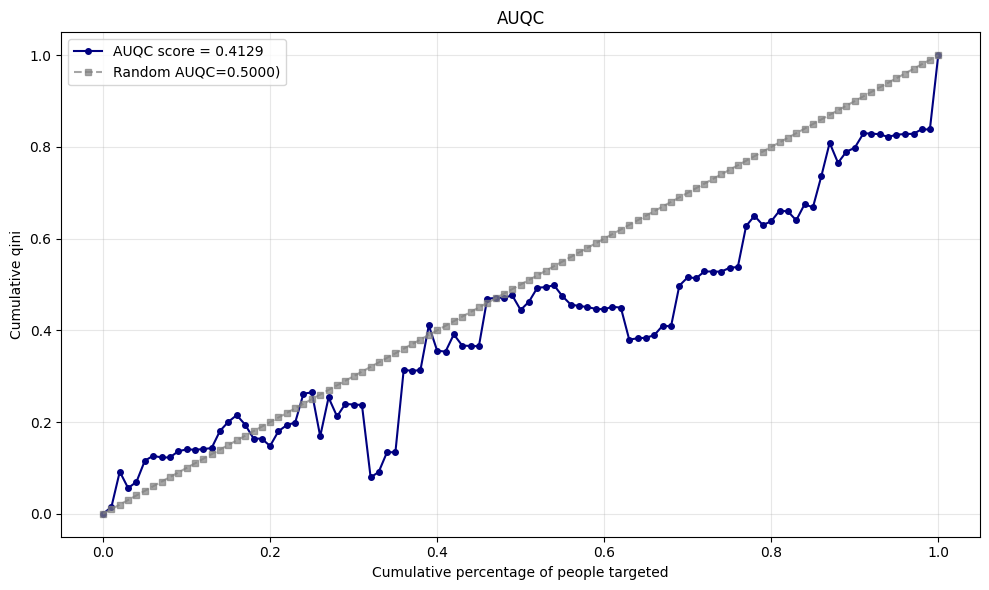

Done Seed 3
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 470.8079 | Tarreg Loss: 233.353012 | Total Loss: 704.1609 | Val Loss: 622.1688 | Val Qini: 0.6277 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 180.5823 | Tarreg Loss: 95.929504 | Total Loss: 276.5118 | Val Loss: 622.8199 | Val Qini: 0.6974 (patience: 1/20)
Epoch 3/150 | Base Loss: 555.0844 | Tarreg Loss: 283.700928 | Total Loss: 838.7853 | Val Loss: 622.4866 | Val Qini: 0.6498 (patience: 2/20)
Epoch 4/150 | Base Loss: 706.5774 | Tarreg Loss: 345.291809 | Total Loss: 1051.8691 | Val Loss: 620.8426 | Val Qini: 0.7600 ⭐ NEW BEST (lowest loss)
Epoch 5/150 | Base Loss: 699.9278 | Tarreg Loss: 350.951660 | Total Loss: 1050.8794 | Val Loss: 620.9141 | Val Qini: 0.7221 (patience: 1/20)
Epoch 6/150 | Base Loss: 33.8849 | Tarreg Loss: 16.676548 | Total Loss: 50.5615 | Val Lo

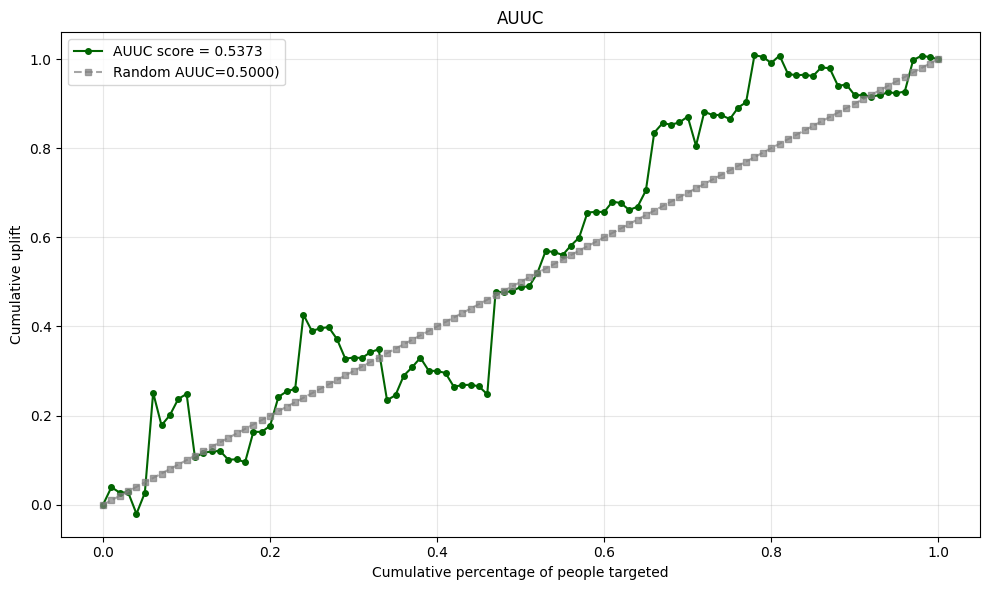

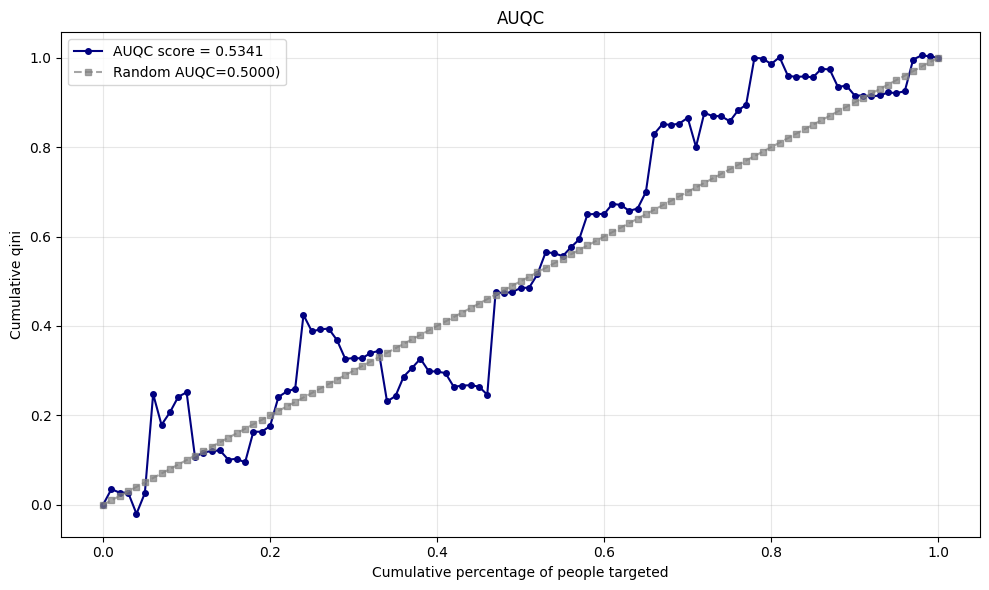

Done Seed 4
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 228.7811 | Tarreg Loss: 113.232727 | Total Loss: 342.0139 | Val Loss: 621.4099 | Val Qini: 0.7971 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 54.6176 | Tarreg Loss: 27.708899 | Total Loss: 82.3265 | Val Loss: 621.0904 | Val Qini: 0.7503 ⭐ NEW BEST (lowest loss)
Epoch 3/150 | Base Loss: 415.9697 | Tarreg Loss: 210.322525 | Total Loss: 626.2922 | Val Loss: 620.8831 | Val Qini: 0.7554 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 1106.1196 | Tarreg Loss: 541.238647 | Total Loss: 1647.3583 | Val Loss: 621.0221 | Val Qini: 0.7374 (patience: 1/20)
Epoch 5/150 | Base Loss: 125.3398 | Tarreg Loss: 63.350796 | Total Loss: 188.6906 | Val Loss: 620.8852 | Val Qini: 0.7685 (patience: 2/20)
Epoch 6/150 | Base Loss: 325.8445 | Tarreg Loss: 160.948349 | Total Loss: 486.7928 

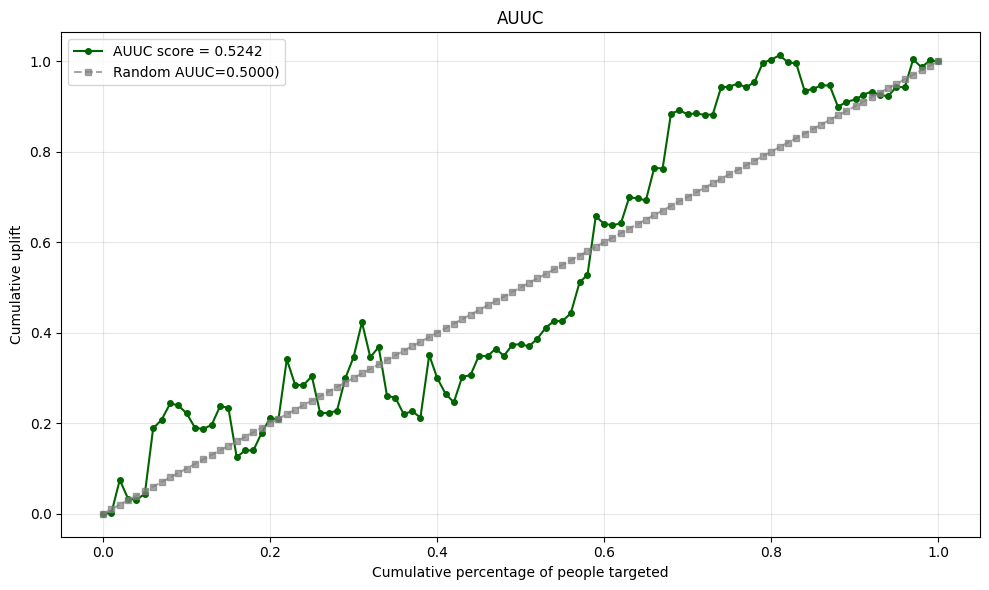

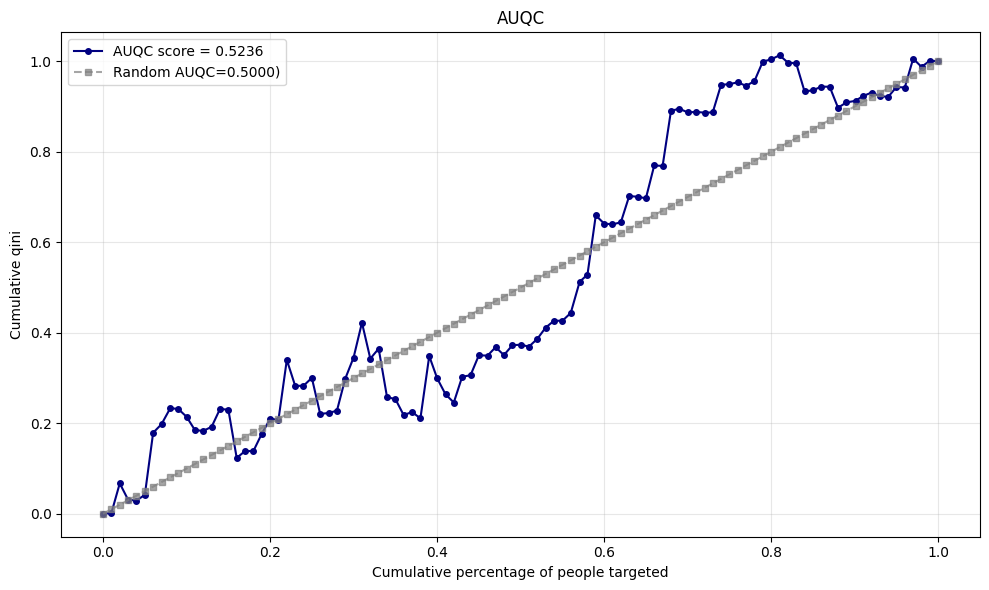

Done Seed 5
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 1328.3969 | Tarreg Loss: 636.484497 | Total Loss: 1964.8813 | Val Loss: 622.6606 | Val Qini: 0.7420 ⭐ NEW BEST (lowest loss)
Epoch 2/150 | Base Loss: 493.6960 | Tarreg Loss: 242.760422 | Total Loss: 736.4564 | Val Loss: 622.8947 | Val Qini: 0.3053 (patience: 1/20)
Epoch 3/150 | Base Loss: 941.9780 | Tarreg Loss: 464.260132 | Total Loss: 1406.2382 | Val Loss: 621.8315 | Val Qini: 0.5593 ⭐ NEW BEST (lowest loss)
Epoch 4/150 | Base Loss: 421.1855 | Tarreg Loss: 220.926163 | Total Loss: 642.1116 | Val Loss: 622.2067 | Val Qini: 0.3236 (patience: 1/20)
Epoch 5/150 | Base Loss: 1010.7131 | Tarreg Loss: 467.742371 | Total Loss: 1478.4556 | Val Loss: 621.3054 | Val Qini: 0.7014 ⭐ NEW BEST (lowest loss)
Epoch 6/150 | Base Loss: 152.2407 | Tarreg Loss: 76.776291 | Total Loss: 229

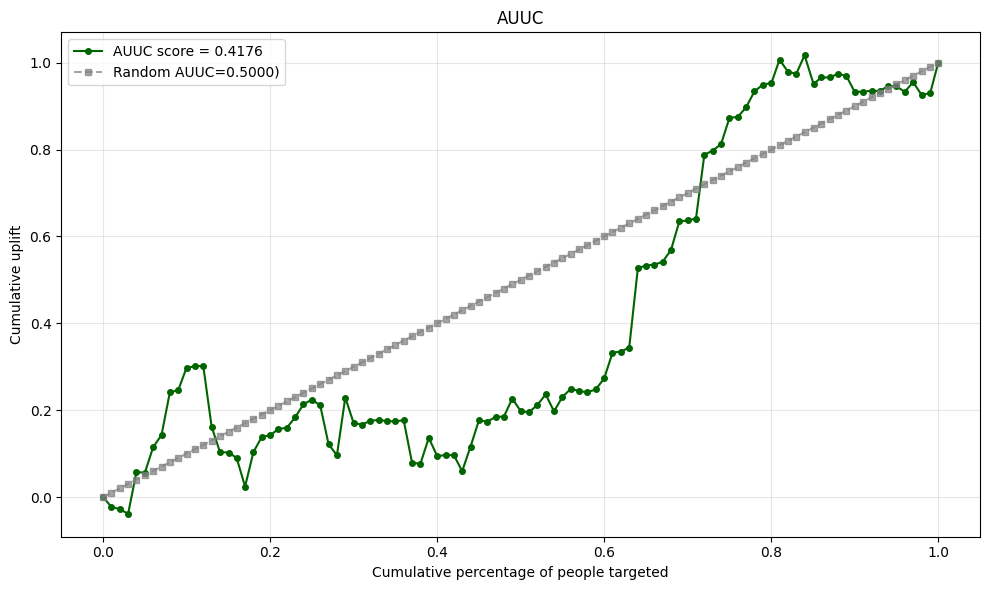

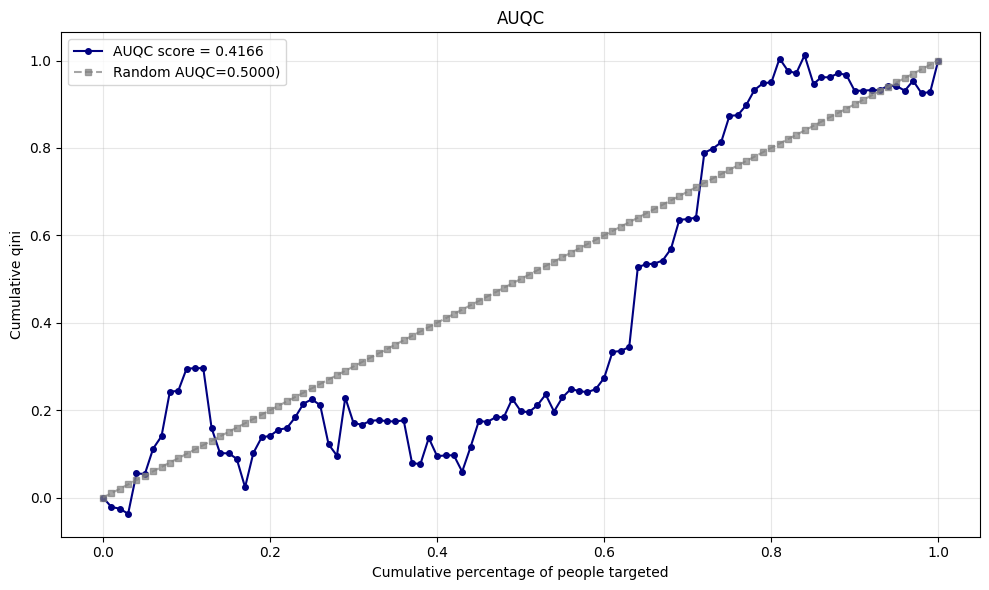

Done Seed 6

                             PER-SEED DETAILS (TEST SET)                             
  Seed   AUUC   AUQC    Lift    KRCC ATE_Err
412312 0.4771 0.4752  0.5241  0.0017  0.8600
    42 0.5538 0.5529  0.4885  0.0401  0.7569
  1874 0.4315 0.4309  0.1710 -0.0225  0.7825
902745 0.3337 0.3338 -0.1719  0.0434  0.0552
     1 0.5251 0.5240  0.8761  0.0309  0.1277
     2 0.4474 0.4465  0.3772  0.0099  0.8521
     3 0.4133 0.4129  0.4682  0.0004  1.3255
     4 0.5373 0.5341  0.6457  0.0120  0.5524
     5 0.5242 0.5236  0.6771  0.0389  1.1074
     6 0.4176 0.4166  0.3350 -0.0492  0.1612
                              TEST SUMMARY (MEAN ± STD)                              
-------------------------------------------------------------------------------------
AUUC      : 0.4661 ± 0.0699
AUQC      : 0.4651 ± 0.0694
Lift      : 0.4391 ± 0.2907
KRCC      : 0.0105 ± 0.0298
ATE_Err   : 0.6581 ± 0.4287


In [5]:
# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1,2,3,4,5,6] # Extended to 10 seeds for more robust evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []


# 2. Loop over seeds for robust test evaluation
for SEED in seeds:
    seed_everything(SEED)

    dragonnet = Dragonnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=150,
        learning_rate=1e-3,
        alpha = 1,
        beta = 1,
        weight_decay=1e-5,
        patience=20,
        shared_hidden=200,
        outcome_hidden=100,
        outcome_dropout=0.0,
        shared_dropout=0.0,
        early_stop_metric="loss",
        early_stop_start_epoch=0
    )

    dragonnet.fit(train_loader, val_loader)

    # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = dragonnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)